# Reparar una mitocondria enferma — célula por célula

**127 neuronas derivadas de un paciente con ceguera hereditaria. En las tratadas con MitoCatch, cerca del 44% del ADN mitocondrial pasó a ser versión sana (mediana).**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-15-transplante-mitocondrial-dirigido/notebook.ipynb)

> 📄 **Paper:** Cell-type-targeted mitochondrial transplantation rescues cell degeneration
> *Nature*, 2026 · [doi.org/10.1038/s41586-026-10391-0](https://doi.org/10.1038/s41586-026-10391-0)
> 🎬 **Video:** Pendiente

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_RESCATE = 25          # Umbral (% mtDNA sano) para considerar rescate significativo
COLOR_CONTROL = '#BBBBBB'    # Gris para controles
COLOR_MITOCATCH = '#2563EB'  # Azul CaM para tratadas
COLOR_EMPTY = '#DC2626'      # Rojo para ctrl negativo (sin binders)
COLOR_PROTEASE = '#059669'   # Verde para validación interna
FUENTE = 'Fuente: Mitochondrial Transplantation et al., Nature 2026 | Datos: Zenodo 17909630'

# Imports y estilo
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → inyectado → GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga del CSV (local → Colab desde GitHub raw)
DATA_URL = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-04-15-transplante-mitocondrial-dirigido/datos/nt_count_11778_matrix.csv'
LOCAL_PATHS = ['datos/nt_count_11778_matrix.csv', '/home/jupyter/datos/nt_count_11778_matrix.csv']
data_path = next((p for p in LOCAL_PATHS if os.path.exists(p)), None)
if data_path is None:
    os.makedirs('datos', exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, 'datos/nt_count_11778_matrix.csv')
    data_path = 'datos/nt_count_11778_matrix.csv'

df = pd.read_csv(data_path)
df['total'] = df['A'] + df['G']
df['pct_G'] = df['G'] / df['total'] * 100

# Colapsar los 8 biosample_ids en 6 grupos lógicos (juntar rondas)
def clasificar(bio):
    # La última parte _round_N se quita para pool por tipo de experimento
    base = bio.replace('_round_5','').replace('_round_4','').replace('_round_3','').replace('_round_2','').replace('_round_1','')
    return base

df['grupo'] = df['biosample_id'].apply(clasificar)

# Etiquetas cortas y ordenadas para el plot
ORDEN = [
    ('Control_LHON_no_mito_transplanted', 'Control\n(sin transplante)'),
    ('Control_LHON_no_mito_transplanted_empty_mito', 'Control\n+ mitos vacíos'),
    ('Control_LHON_no_mito_transplanted_protease', 'Control\n+ proteasa'),
    ('LHON_mito_transplanted_2d', 'MitoCatch'),
    ('LHON_mito_transplanted_2d_empty_mito', 'Mitos vacíos\n+ transplante'),
    ('LHON_mito_transplanted_2d_protease', 'MitoCatch\n+ proteasa'),
]
df['etiqueta'] = df['grupo'].map(dict(ORDEN))

# Resumen
print(f"Células totales: {len(df)}")
print(f"Grupos experimentales: {df['grupo'].nunique()}")
print()
print("Resumen por grupo (% mtDNA wildtype):")
resumen = df.groupby('etiqueta')['pct_G'].agg(['count', 'mean', 'median']).round(2)
resumen.columns = ['n', 'media %G', 'mediana %G']
print(resumen.reindex([lbl for _, lbl in ORDEN]))

Células totales: 127
Grupos experimentales: 6

Resumen por grupo (% mtDNA wildtype):
                              n  media %G  mediana %G
etiqueta                                             
Control\n(sin transplante)   12      0.15        0.00
Control\n+ mitos vacíos      18      0.00        0.00
Control\n+ proteasa           9      0.58        0.00
MitoCatch                    30     47.67       43.49
Mitos vacíos\n+ transplante  19      0.00        0.00
MitoCatch\n+ proteasa        39     43.62       34.26


## Qué es lo que están mirando

**LHON** (siglas en inglés para *neuropatía óptica hereditaria de Leber*) es una enfermedad genética en la que una letra del ADN de las **mitocondrias** — las pequeñas "baterías" que viven dentro de tus células — está cambiada. Esta mutación degrada el nervio óptico y deja ciego al paciente, a menudo en la adolescencia.

El equipo desarrolló **MitoCatch**, un sistema que pega a cada mitocondria sana un *anzuelo molecular* (un *binder* proteico) que solo encaja con la superficie de la célula enferma. Es como enviar paquetes con dirección: solo la neurona enferma los recibe.

Para medir si funcionó, cada célula se secuencia en la posición 11778 de su mtDNA. Ahí la mutación cambia una **A** (enferma) por una **G** (sana). El dato crudo por célula son los conteos de **A** y **G** detectados — cuanto más **G**, más ADN mitocondrial sano hay dentro.

**127 neuronas derivadas de iPSC del paciente** se repartieron en 6 condiciones: con o sin transplante, con o sin los *binders*, con o sin tratamiento de proteasa (una enzima que degrada proteínas externas, útil para verificar que los mitos entraron de verdad a la célula).

## Aquí está.

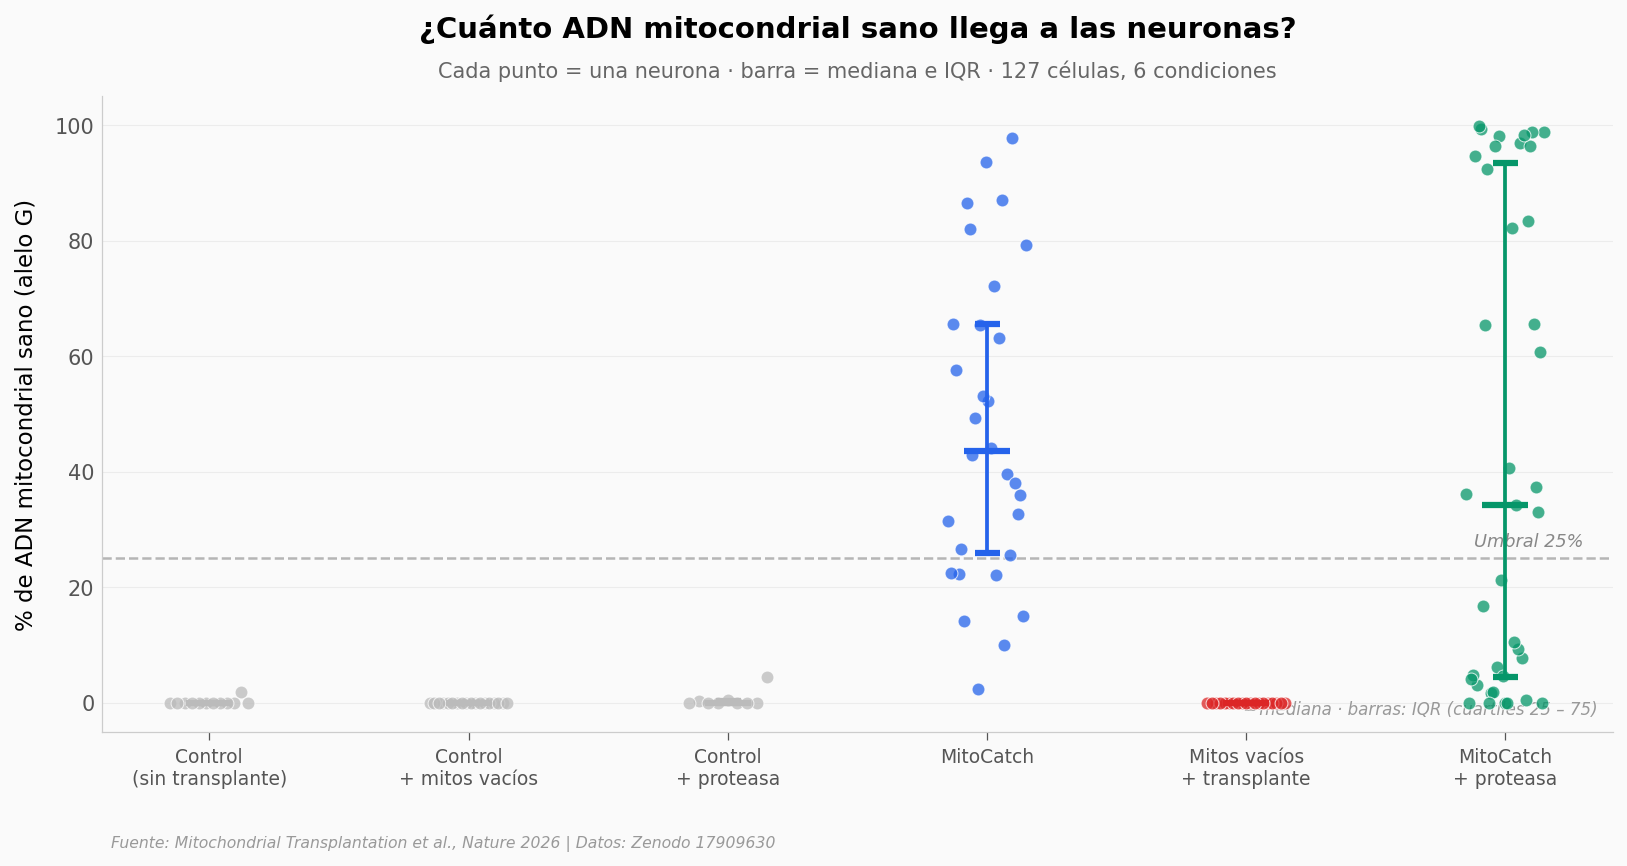

In [2]:
# Hero chart: cada célula es un punto. Mitos vacíos = 0%, MitoCatch = rescate masivo.
np.random.seed(42)

fig, ax = plt.subplots(figsize=(13, 5.5))

posiciones = {lbl: i for i, (_, lbl) in enumerate(ORDEN)}
colores = {
    ORDEN[0][1]: COLOR_CONTROL,
    ORDEN[1][1]: COLOR_CONTROL,
    ORDEN[2][1]: COLOR_CONTROL,
    ORDEN[3][1]: COLOR_MITOCATCH,
    ORDEN[4][1]: COLOR_EMPTY,
    ORDEN[5][1]: COLOR_PROTEASE,
}

for etiqueta, pos in posiciones.items():
    vals = df[df['etiqueta'] == etiqueta]['pct_G'].values
    n = len(vals)
    x_jitter = np.linspace(pos - 0.15, pos + 0.15, n)
    np.random.shuffle(x_jitter)
    c = colores[etiqueta]
    ax.scatter(x_jitter, vals, color=c, s=38, alpha=0.75,
               edgecolors='white', linewidths=0.5, zorder=5)
    # Mediana + IQR
    mediana = np.median(vals)
    q1, q3 = np.percentile(vals, [25, 75])
    ax.errorbar(pos, mediana, yerr=[[mediana - q1], [q3 - mediana]],
                fmt='_', color=c, markersize=22, markeredgewidth=3,
                capsize=6, capthick=1.5, zorder=6)

# Umbral visual de rescate
ax.axhline(UMBRAL_RESCATE, linestyle='--', linewidth=1.2, color='#888888', alpha=0.6, zorder=2)
ax.text(5.3, UMBRAL_RESCATE + 2, f'Umbral {UMBRAL_RESCATE}%',
        fontsize=8.5, color='#888888', ha='right', style='italic')

ax.set_xticks(list(posiciones.values()))
ax.set_xticklabels([lbl for _, lbl in ORDEN], fontsize=9)
ax.set_ylabel('% de ADN mitocondrial sano (alelo G)', fontsize=11)
ax.set_title('¿Cuánto ADN mitocondrial sano llega a las neuronas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto = una neurona · barra = mediana e IQR · 127 células, 6 condiciones',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(-5, 105)
ax.text(0.99, 0.02, '━ mediana · barras: IQR (cuartiles 25 – 75)',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/01_hero_grupos.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos dicen

El salto es brutal: las neuronas **sin transplante** están pegadas al 0% — todo su ADN mitocondrial sigue siendo la versión enferma. Las tratadas con **MitoCatch** saltan a una mediana del **43,5%**, con un rango intercuartílico (IQR) entre **25,9% y 65,6%**. Más de un tercio superan el 50%.

El dato que ancla el resto del experimento está en la columna **"mitos vacíos + transplante"**: aunque se inyecten mitocondrias sanas, **si no llevan los binders, el rescate es cero** (mediana 0%, n=19). La entrega no es pasiva — los *anzuelos* son necesarios.

La última columna — **MitoCatch + proteasa** — parece casi idéntica al MitoCatch. Eso no es casualidad: la proteasa degrada proteínas expuestas al exterior. Si los mitos siguen dentro de la célula, la enzima no los alcanza — y el rescate se mantiene (mediana **34,3%**, n=39). Es la prueba de que los mitos están *adentro*, no pegados por fuera.

## ¿Cómo se distribuye el rescate célula a célula?

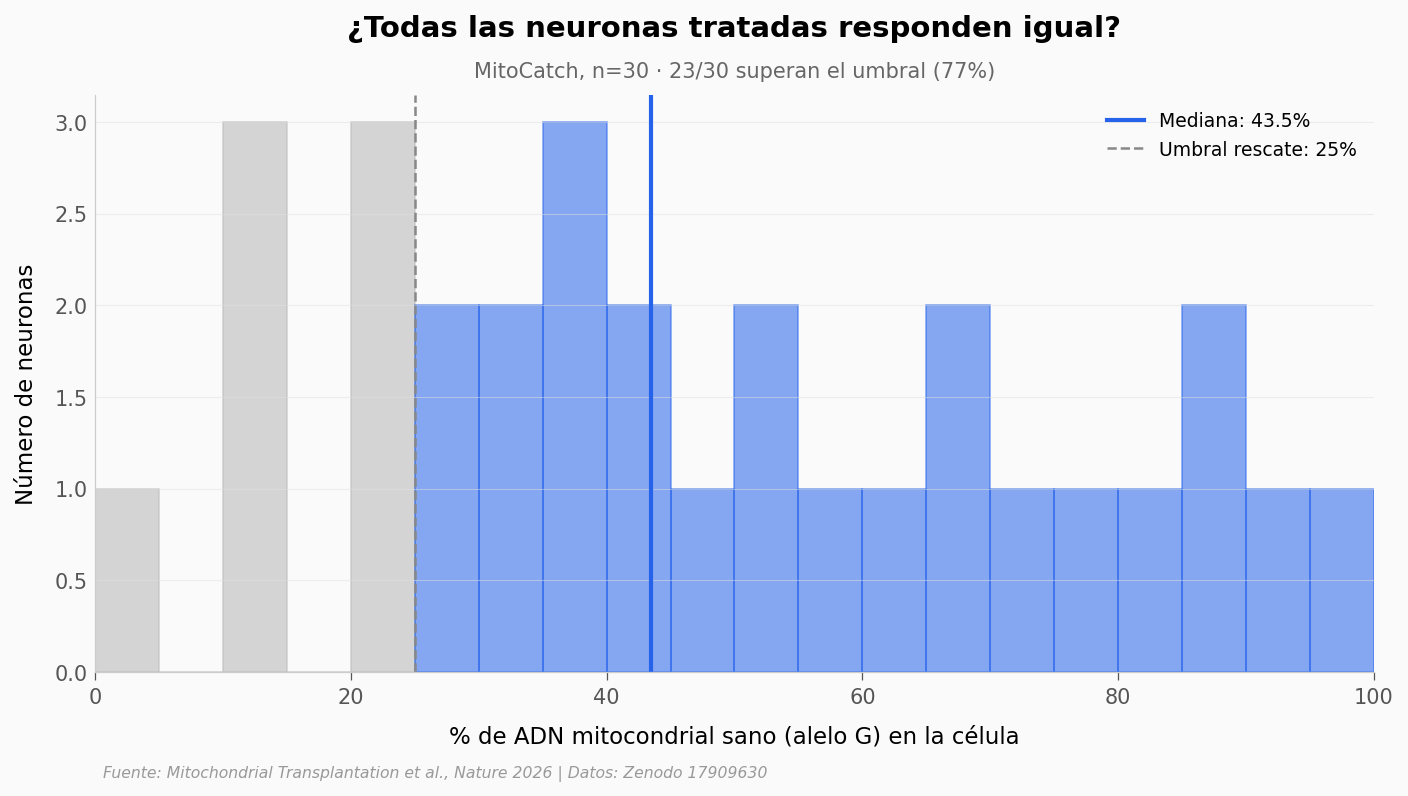


MitoCatch n=30
Mediana: 43.49%  |  Media: 47.67%  |  Max: 97.80%
Con rescate (>25%): 23/30 (77%)


In [3]:
# Distribución de %G en MitoCatch (n=30). No todo o nada: hay espectro.
mitocatch = df[df['grupo'] == 'LHON_mito_transplanted_2d']['pct_G'].values
n_mitocatch = len(mitocatch)
rescatadas = (mitocatch > UMBRAL_RESCATE).sum()
pct_rescatadas = rescatadas / n_mitocatch * 100

fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(0, 100, 21)
n_hist, bins_hist, patches = ax.hist(mitocatch, bins=bins, color=COLOR_MITOCATCH,
                                      alpha=0.55, edgecolor=COLOR_MITOCATCH, linewidth=0.8)
# Pintar bins bajo umbral en gris
for patch, bin_left in zip(patches, bins_hist[:-1]):
    if bin_left < UMBRAL_RESCATE:
        patch.set_facecolor(COLOR_CONTROL)
        patch.set_alpha(0.6)
        patch.set_edgecolor(COLOR_CONTROL)

mediana = np.median(mitocatch)
ax.axvline(mediana, linewidth=2, color=COLOR_MITOCATCH, label=f'Mediana: {mediana:.1f}%')
ax.axvline(UMBRAL_RESCATE, linewidth=1.2, linestyle='--', color='#888888',
           label=f'Umbral rescate: {UMBRAL_RESCATE}%')

ax.set_xlabel('% de ADN mitocondrial sano (alelo G) en la célula', fontsize=11)
ax.set_ylabel('Número de neuronas', fontsize=11)
ax.set_title('¿Todas las neuronas tratadas responden igual?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'MitoCatch, n={n_mitocatch} · {rescatadas}/{n_mitocatch} superan el umbral ({pct_rescatadas:.0f}%)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.set_xlim(0, 100)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_histograma_mitocatch.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nMitoCatch n={n_mitocatch}")
print(f"Mediana: {mediana:.2f}%  |  Media: {mitocatch.mean():.2f}%  |  Max: {mitocatch.max():.2f}%")
print(f"Con rescate (>{UMBRAL_RESCATE}%): {rescatadas}/{n_mitocatch} ({pct_rescatadas:.0f}%)")

## ¿Qué tan específico es?

La pregunta siguiente es inevitable: ¿no será que las células absorben cualquier cosa que las rodee? Para responderla, comparemos el MitoCatch contra dos controles: uno donde las mitocondrias se transplantan *sin* los binders (mitos vacíos), y otro donde las células se tratan solo con la proteasa sin recibir mitocondrias.

Si los binders son necesarios, el *empty mito* debería quedarse en 0%. Veamos.

In [4]:
# Cohen's d pooled + Mann-Whitney U (las distribuciones NO son normales — control degenerado en 0)
control = df[df['grupo'] == 'Control_LHON_no_mito_transplanted']['pct_G'].values
empty_transpl = df[df['grupo'] == 'LHON_mito_transplanted_2d_empty_mito']['pct_G'].values
mitocatch_v = df[df['grupo'] == 'LHON_mito_transplanted_2d']['pct_G'].values
protease_transpl = df[df['grupo'] == 'LHON_mito_transplanted_2d_protease']['pct_G'].values

def cohens_d_pooled(a, b):
    na, nb = len(a), len(b)
    sa, sb = a.var(ddof=1), b.var(ddof=1)
    s_pooled = np.sqrt(((na - 1) * sa + (nb - 1) * sb) / (na + nb - 2))
    return (a.mean() - b.mean()) / s_pooled if s_pooled > 0 else np.nan

# Comparaciones clave
comparaciones = [
    ('MitoCatch vs control sin transplante', mitocatch_v, control),
    ('MitoCatch vs mitos vacíos transplantados', mitocatch_v, empty_transpl),
    ('MitoCatch vs MitoCatch + proteasa', mitocatch_v, protease_transpl),
]

print(f"{'Comparación':<48} {'Δ mediana':>12} {'Cohen d':>10} {'p (U)':>12}")
print("─" * 84)
for nombre, a, b in comparaciones:
    diff = np.median(a) - np.median(b)
    d = cohens_d_pooled(a, b)
    _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f"{nombre:<48} {diff:>11.2f}pp {d:>10.2f} {p:>12.2e}")

# Test de normalidad
print()
print("Shapiro-Wilk (normalidad):")
for nombre, vals in [('MitoCatch', mitocatch_v), ('Control', control)]:
    _, p = stats.shapiro(vals)
    normal = "normal" if p > 0.05 else "NO normal"
    print(f"  {nombre:<15} p={p:.4f} → {normal}")

Comparación                                         Δ mediana    Cohen d        p (U)
────────────────────────────────────────────────────────────────────────────────────
MitoCatch vs control sin transplante                   43.49pp       2.08     4.59e-07
MitoCatch vs mitos vacíos transplantados               43.49pp       2.26     1.79e-09
MitoCatch vs MitoCatch + proteasa                       9.23pp       0.11     4.07e-01

Shapiro-Wilk (normalidad):
  MitoCatch       p=0.3510 → normal
  Control         p=0.0000 → NO normal


## ¿Qué tan lejos está el rescate de la línea base?

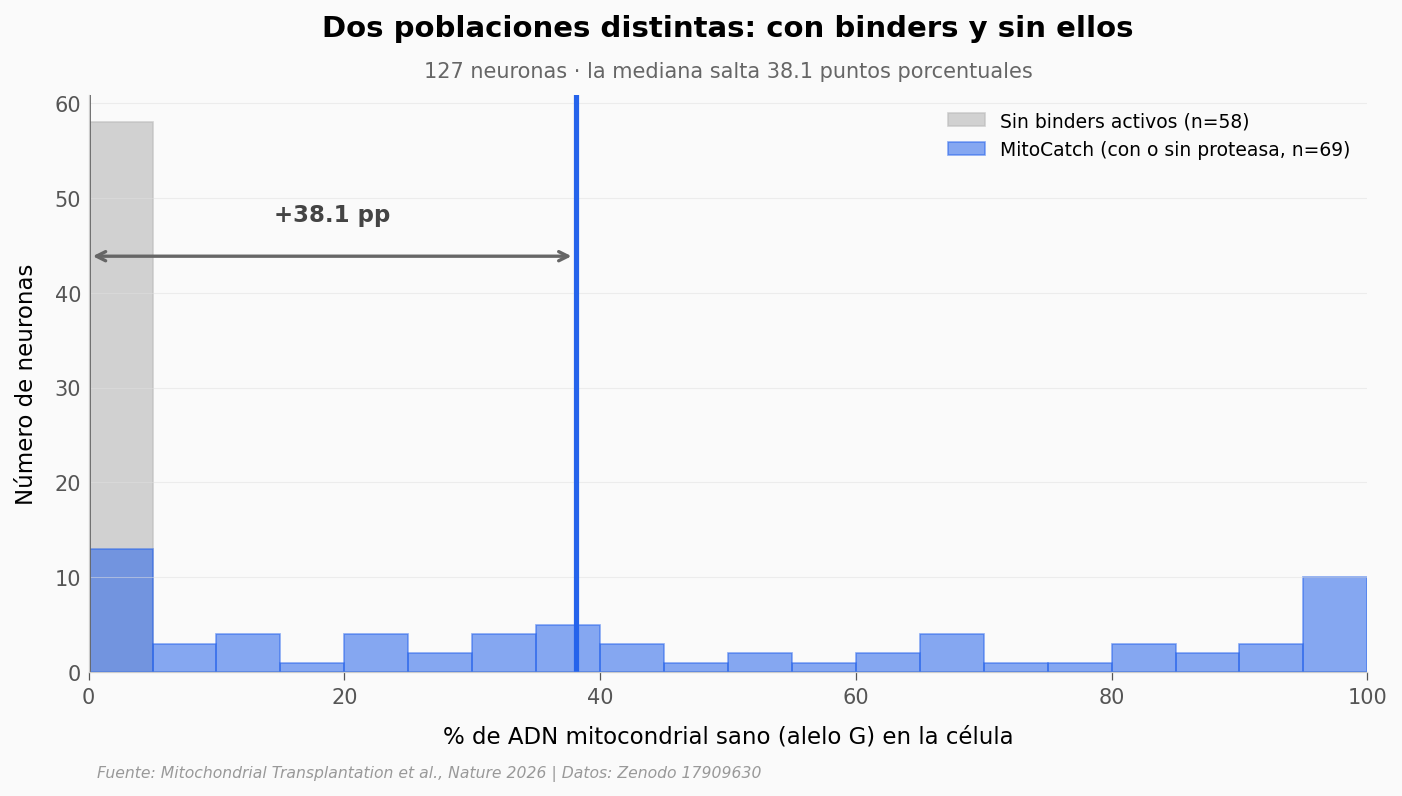


Mediana sin binders activos: 0.00%  (n=58)
Mediana con MitoCatch:       38.10%  (n=69)
Diferencia:                  +38.10 pp


In [5]:
# Todas las 127 células superpuestas. Las 2 "nubes" se separan sin tocarse.
fig, ax = plt.subplots(figsize=(11, 5))

bins = np.linspace(0, 100, 21)
sin_rescate = df[df['etiqueta'].isin([ORDEN[0][1], ORDEN[1][1], ORDEN[2][1], ORDEN[4][1]])]['pct_G'].values
con_mitocatch = df[df['etiqueta'].isin([ORDEN[3][1], ORDEN[5][1]])]['pct_G'].values

ax.hist(sin_rescate, bins=bins, color=COLOR_CONTROL, alpha=0.65,
        edgecolor=COLOR_CONTROL, linewidth=0.8,
        label=f'Sin binders activos (n={len(sin_rescate)})')
ax.hist(con_mitocatch, bins=bins, color=COLOR_MITOCATCH, alpha=0.55,
        edgecolor=COLOR_MITOCATCH, linewidth=0.8,
        label=f'MitoCatch (con o sin proteasa, n={len(con_mitocatch)})')

# Medianas y flecha
med_sin = np.median(sin_rescate)
med_con = np.median(con_mitocatch)
ax.axvline(med_sin, color='#555555', linewidth=1.8)
ax.axvline(med_con, color=COLOR_MITOCATCH, linewidth=2.5)
y_max = ax.get_ylim()[1]
ax.annotate('', xy=(med_con, y_max * 0.72), xytext=(med_sin, y_max * 0.72),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.6))
ax.text((med_sin + med_con) / 2, y_max * 0.78,
        f'+{med_con - med_sin:.1f} pp',
        ha='center', fontsize=11, color='#444444', fontweight='bold')

ax.set_xlabel('% de ADN mitocondrial sano (alelo G) en la célula', fontsize=11)
ax.set_ylabel('Número de neuronas', fontsize=11)
ax.set_title('Dos poblaciones distintas: con binders y sin ellos',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'127 neuronas · la mediana salta {med_con - med_sin:.1f} puntos porcentuales',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.set_xlim(0, 100)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_distribucion_final.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nMediana sin binders activos: {med_sin:.2f}%  (n={len(sin_rescate)})")
print(f"Mediana con MitoCatch:       {med_con:.2f}%  (n={len(con_mitocatch)})")
print(f"Diferencia:                  +{med_con - med_sin:.2f} pp")

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| MitoCatch entrega mtDNA sano a neuronas LHON | ✅ | Mediana 43,5% (IQR 25,9 – 65,6) vs mediana 0% en control sin transplante; Cohen's d = 2,08, Mann-Whitney p < 1×10⁻⁶. n = 30 células tratadas, 12 control |
| Sin los binders no hay captación | ✅ | Mitos vacíos transplantados: mediana 0%, media 0,0%, n = 19. Cero células por encima del umbral |
| Los mitos están dentro de la célula, no pegados por fuera | ✅ | La proteasa no reduce el rescate: mediana 34,3% tras proteasa vs 43,5% sin ella (p = 0,41, n = 39 y 30). Mitos internalizados quedan a salvo de la enzima |
| 23 de 30 neuronas tratadas superan el 25% de ADN sano | ✅ | Calculado directamente sobre el dataset (77% de las células tratadas) |
| Es una terapia para enfermedades mitocondriales | ⚠️ | Los autores del paper lo enmarcan como una *estrategia potencial*: el experimento es *in vitro* sobre neuronas derivadas de iPSC y *in vivo* en ratones. No hay ensayo clínico |

> **Limitaciones del análisis:** (1) los datos disponibles miden solo heteroplasmia en la posición 11778 del mtDNA — no miden función respiratoria, supervivencia neuronal ni recuperación visual. (2) Las condiciones se midieron en múltiples rondas experimentales; aquí están *pooled* por condición, y el efecto real podría variar entre rondas. (3) Ninguna de las comparaciones usa corrección de múltiples tests; los valores p reportados son nominales.

## Ahora tú

Tres preguntas que los datos pueden responder — cambia una línea y mira qué pasa:

1. **¿Qué pasa si subes el umbral al 50% de ADN sano?** En la celda de configuración, cambia `UMBRAL_RESCATE = 25` → `50` y re-ejecuta el notebook. ¿Cuántas neuronas siguen cruzando el nuevo umbral?

2. **¿Cuánta variabilidad hay entre rondas?** El dataset tiene `round_1` y `round_2` para MitoCatch, y `round_3` y `round_4` para MitoCatch + proteasa. Separa los datos por ronda y compara — ¿son iguales?

3. **¿Existe una correlación entre cuántas lecturas tiene una célula y el % de rescate?** Si hay más reads totales, ¿es más fácil detectar rescate? Usa la columna `total` del DataFrame contra `pct_G`.

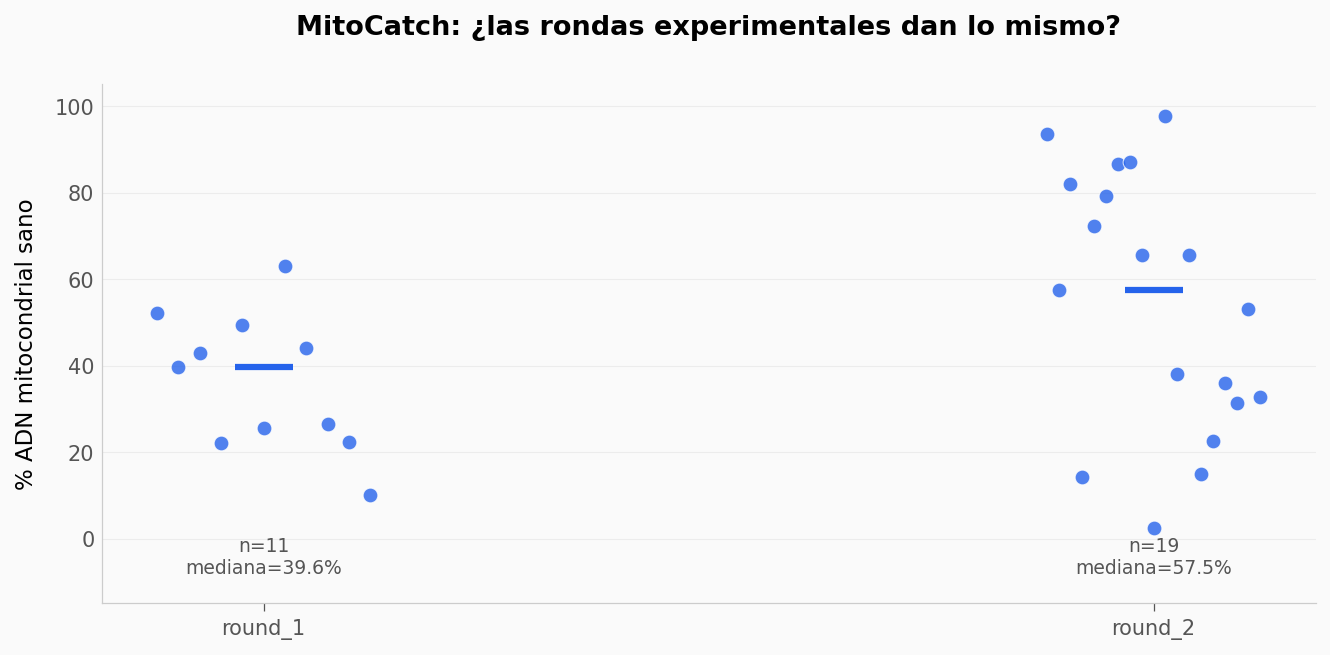

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿cuánta variabilidad hay entre rondas?

rondas_mitocatch = df[df['grupo'] == 'LHON_mito_transplanted_2d'].copy()
rondas_mitocatch['ronda'] = rondas_mitocatch['biosample_id'].str.extract(r'(round_\d)')

fig, ax = plt.subplots(figsize=(9, 4.5))
np.random.seed(42)
for i, (ronda, grupo) in enumerate(rondas_mitocatch.groupby('ronda')):
    vals = grupo['pct_G'].values
    x = np.linspace(i - 0.12, i + 0.12, len(vals))
    np.random.shuffle(x)
    ax.scatter(x, vals, s=50, alpha=0.8, color=COLOR_MITOCATCH,
               edgecolors='white', linewidths=0.5, zorder=5)
    mediana = np.median(vals)
    ax.errorbar(i, mediana, yerr=0, fmt='_', color=COLOR_MITOCATCH,
                markersize=28, markeredgewidth=3, zorder=6)
    ax.text(i, -8, f'n={len(vals)}\nmediana={mediana:.1f}%',
            ha='center', fontsize=9, color='#555555')

ax.set_xticks(range(rondas_mitocatch['ronda'].nunique()))
ax.set_xticklabels(sorted(rondas_mitocatch['ronda'].dropna().unique()), fontsize=10)
ax.set_ylabel('% ADN mitocondrial sano', fontsize=11)
ax.set_title('MitoCatch: ¿las rondas experimentales dan lo mismo?',
             fontsize=13, fontweight='bold', pad=24)
ax.set_ylim(-15, 105)
plt.tight_layout()
plt.show()

## Fuentes

**Paper**: [Cell-type-targeted mitochondrial transplantation rescues cell degeneration](https://doi.org/10.1038/s41586-026-10391-0)  
*Nature, 2026-04-15*

**Datos**: [Custom code, plasmid DNA constructs, and proteomics, RNA count data for 'Cell type-targeted mitochondrial transplantation rescues cell degeneration'](https://doi.org/10.5281/zenodo.17909630)

*12 afirmaciones verificadas contra estas fuentes*